In [25]:
import kidpy3 as kp
import numpy as np
import matplotlib
%matplotlib widget
import matplotlib.pyplot as plt
from kidpy3.hardware import Valon5009
from kidpy3.hardware import Transceiver321
from kidpy3.measure import losweep
import importlib

In [26]:
dev = kp.RFSOC("readout.yml")

In [27]:
lo = Valon5009("/dev/ttyUSB0")
att = Transceiver321("/dev/ttyACM0")

Checking for baud 115200
something went wrong when hunting for valon baudrates
[b'\x00']
Checking for baud 9600
Connected at baud 9600
Connected


In [28]:
dev.rf1.chanmask = np.zeros(1)


In [29]:
dev.upload_bitstream()
dev.config_hardware()

True

## Set your baseband tones here

In [51]:
# bb = np.array([50.371e6])
bb =  np.linspace(-245.137e6, 254.113e6, 1000)
dev.set_tone_list(chan=1, tonelist=bb, amplitudes=np.ones_like(bb))
true_bb = dev.get_tone_list(1)

## Set your LO Source Here
1 as in "source 1" which you can see in the open enclosure

In [42]:
lofreq = 990
dev.rf1.lo_freq = lofreq
lo.set_frequency(1, lofreq)
lo.set_rf_level(1, 10)

b'F 990 MHz; // Act 990 MHz\r\n'


True

## Set your atten here

In [44]:
# RFOUT (DRIVE) Attenuation  ( 0 - 31.75 in 0.25 increments )
att.set_atten(addr=1, value=14)

(True, 'OK')

In [52]:
# RFIN (SENSE) Attenuation
att.set_atten(addr=2, value=4)

(True, 'OK')

## Do a sweep


In [10]:
sfreq, s21 = losweep(lo, dev.rf1, dev.rf1.lo_freq, true_bb[0], naccums=10)
print(sfreq.shape, s21.shape)

b'F 989.77515 MHz; // Act 989.775151 MHz\r\n'
.b'F 989.776049 MHz; // Act 989.776049 MHz\r\n'
.b'F 989.776948 MHz; // Act 989.776951 MHz\r\n'
.b'F 989.777848 MHz; // Act 989.777848 MHz\r\n'
.b'F 989.778747 MHz; // Act 989.778747 MHz\r\n'
.b'F 989.779647 MHz; // Act 989.779647 MHz\r\n'
.b'F 989.780546 MHz; // Act 989.780545 MHz\r\n'
.b'F 989.781445 MHz; // Act 989.781445 MHz\r\n'
.b'F 989.782345 MHz; // Act 989.782345 MHz\r\n'
.b'F 989.783244 MHz; // Act 989.783243 MHz\r\n'
.b'F 989.784144 MHz; // Act 989.784144 MHz\r\n'
.b'F 989.785043 MHz; // Act 989.785042 MHz\r\n'
.b'F 989.785942 MHz; // Act 989.785941 MHz\r\n'
.b'F 989.786842 MHz; // Act 989.786842 MHz\r\n'
.b'F 989.787741 MHz; // Act 989.787742 MHz\r\n'
.b'F 989.788641 MHz; // Act 989.788639 MHz\r\n'
.b'F 989.78954 MHz; // Act 989.78954 MHz\r\n'
.b'F 989.790439 MHz; // Act 989.790438 MHz\r\n'
.b'F 989.791339 MHz; // Act 989.791338 MHz\r\n'
.b'F 989.792238 MHz; // Act 989.792238 MHz\r\n'
.b'F 989.793138 MHz; // Act 989.793138 MHz\r

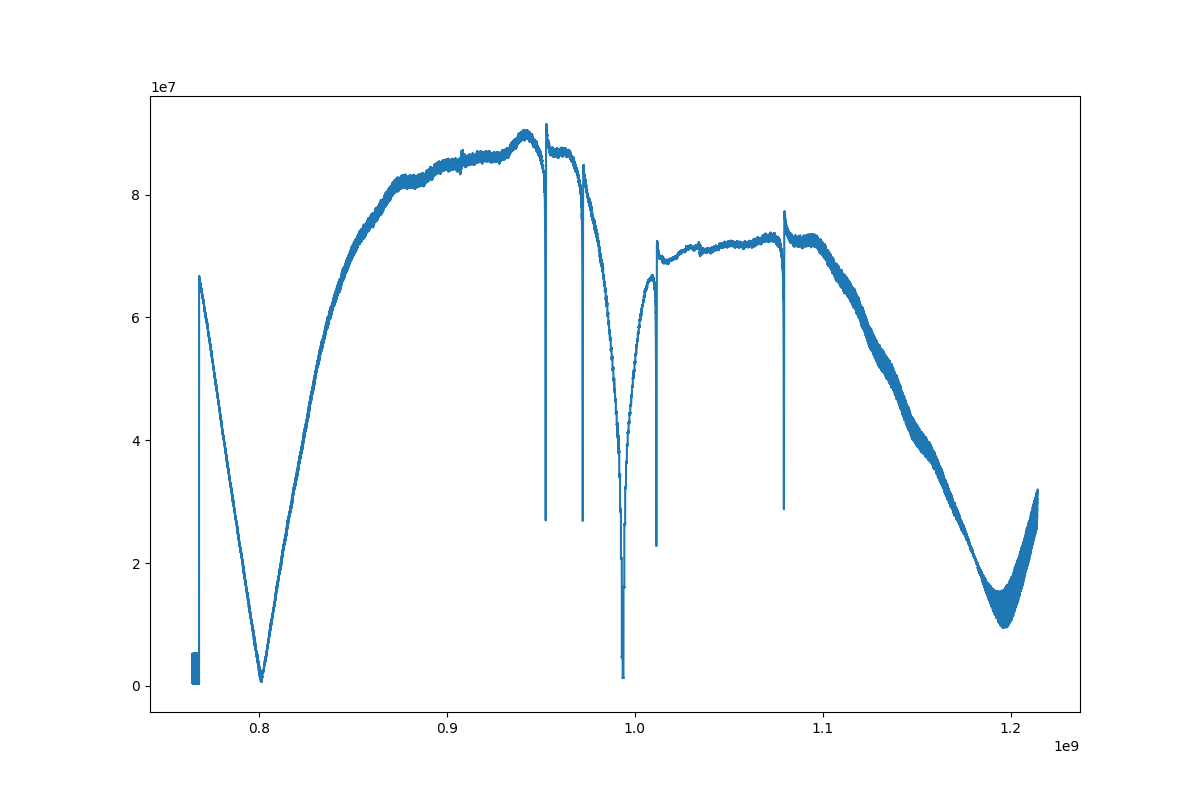

In [11]:
plt.figure(figsize=(12,8))
plt.plot(sfreq.flatten()
, np.abs(s21).flatten())
plt.show()

In [12]:
# Save Results
np.save("sweepfreqs", sfreq)
np.save("s21", s21)

## Find Resonators

In [56]:
from kidpy3.measure import ResonatorFinder

In [57]:
loaded_sfreq = np.load("sweepfreqs.npy")
loaded_s21 = np.load("s21.npy")

In [58]:
rfind = ResonatorFinder((loaded_sfreq, loaded_s21), dev.rf1.lo_freq, np.diff(loaded_sfreq.flatten())[0]/1e6)

In [59]:
targfreqs = rfind.find_resonators(6, 3, 10)

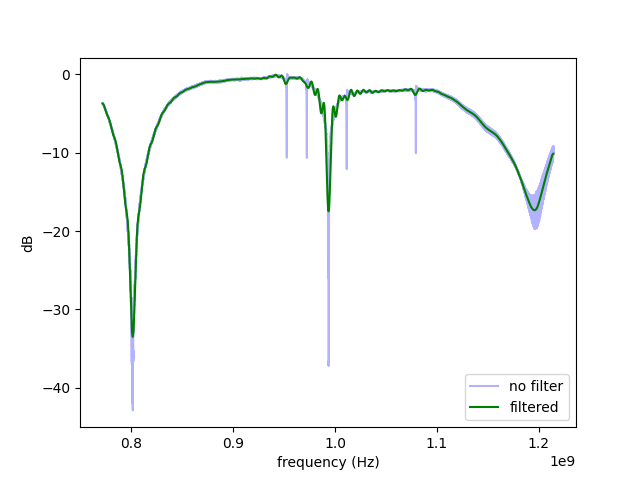

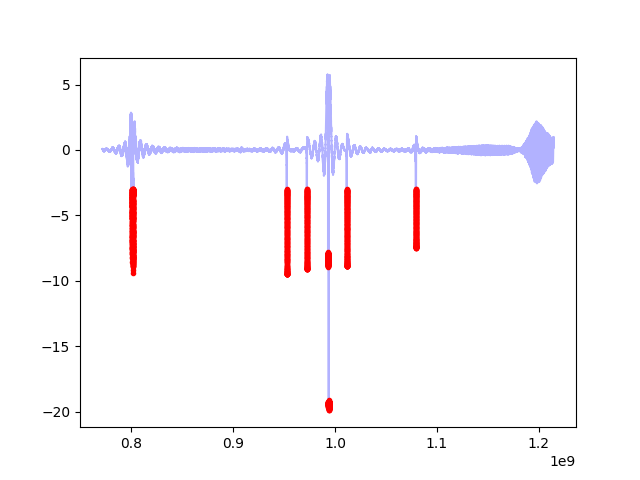

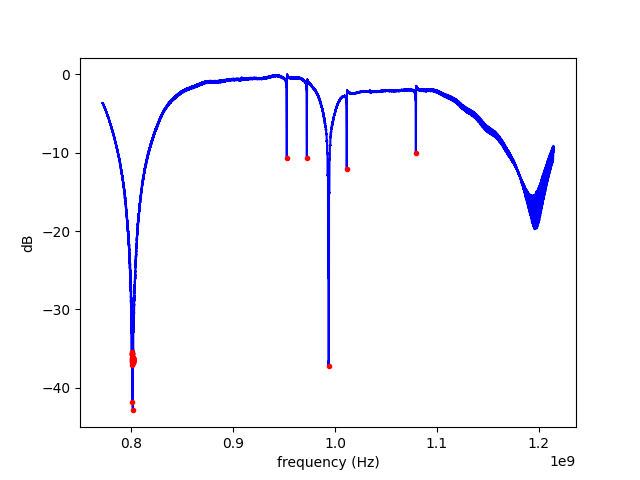

In [60]:
rfind.plot()

In [71]:
import pandas as pd
upconverted_targfreqs = (targfreqs+990e6)/1e6
print((np.sort(upconverted_targfreqs) - 990e6)[-1])


-989998920.6736922


In [62]:
b

,0
0,21.481104
1,89.327298
2,-189.440647
3,-189.438848
4,-189.434351
5,-189.430753
6,-189.428055
7,-189.426256
8,-189.424457
9,-189.386683
